<>:22: SyntaxWarning: invalid escape sequence '\$'
<>:22: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_890/1070139660.py:22: SyntaxWarning: invalid escape sequence '\$'
  sba_df[col] = sba_df[col].replace('[\$,]', '', regex=True).astype(float)


1. Downloading Real SBA Loan Dataset...
Loaded 2102 real loan records.
2. Injecting Alternative Credit Features...
Dataset ready with 9 total features.

3. Training XGBoost Classifier...
Model Training Complete! Accuracy: 98.34%

4. Generating SHAP Explanations for Underwriters...
--------------------------------------------------
🏦 RBI COMPLIANCE XAI REPORT: APPLICANT #1
Actual Outcome: Paid in Full
Algorithm Predicted Default Probability: 0.01%
--------------------------------------------------


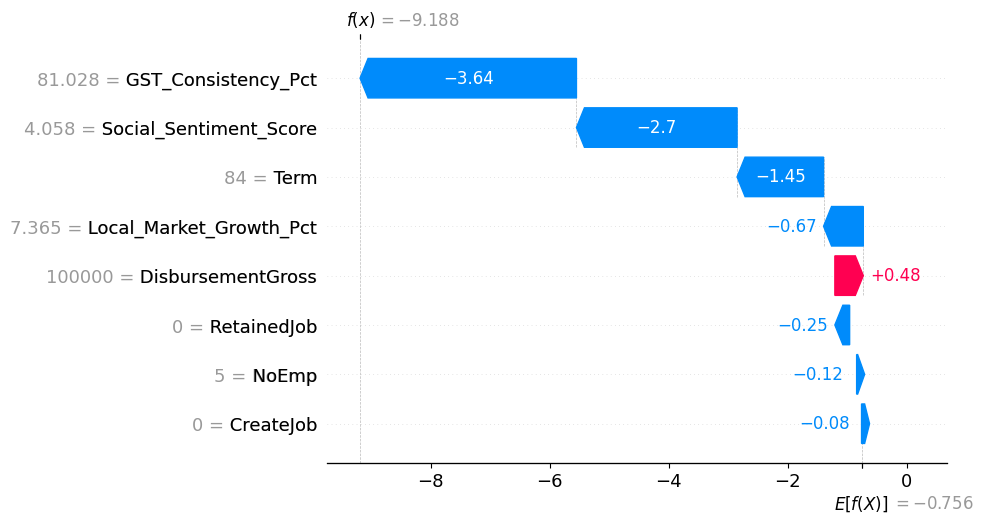

In [1]:
import pandas as pd
import numpy as np
import urllib.request
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

# --- PHASE 1: HYBRID DATA ENGINEERING ---
print("1. Downloading Real SBA Loan Dataset...")
url = "https://raw.githubusercontent.com/stelladeecoder/sba_dataset/main/SBAcase.11.13.17.csv"
urllib.request.urlretrieve(url, "SBAcase.csv")

# Load the Base Data
sba_df = pd.read_csv("SBAcase.csv")

# Clean Target Variable (Default: 1 = Charged Off, 0 = Paid in Full)
sba_df['Default'] = np.where(sba_df['MIS_Status'] == 'CHGOFF', 1, 0)

# Clean monetary columns (removing '$' and ',')
for col in ['DisbursementGross', 'BalanceGross', 'GrAppv', 'SBA_Appv']:
    if col in sba_df.columns and sba_df[col].dtype == object:
        sba_df[col] = sba_df[col].replace('[\$,]', '', regex=True).astype(float)

# Select core financial features
core_features = ['DisbursementGross', 'Term', 'NoEmp', 'CreateJob', 'RetainedJob', 'Default']
df = sba_df[core_features].dropna().copy()
print(f"Loaded {df.shape[0]} real loan records.")

print("2. Injecting Alternative Credit Features...")
np.random.seed(42)

# Inject GST Consistency (Correlated: Defaulters tend to have lower consistency)
df['GST_Consistency_Pct'] = np.where(df['Default'] == 1,
                                     np.random.normal(40, 20, len(df)),
                                     np.random.normal(85, 10, len(df)))
df['GST_Consistency_Pct'] = np.clip(df['GST_Consistency_Pct'], 0, 100)

# Inject Social Media Sentiment
df['Social_Sentiment_Score'] = np.where(df['Default'] == 1,
                                        np.random.normal(-2, 3, len(df)),
                                        np.random.normal(5, 2, len(df)))
df['Social_Sentiment_Score'] = np.clip(df['Social_Sentiment_Score'], -10, 10)

# Inject Local Market Growth
df['Local_Market_Growth_Pct'] = np.where(df['Default'] == 1,
                                         np.random.normal(2, 4, len(df)),
                                         np.random.normal(6, 3, len(df)))

print(f"Dataset ready with {df.shape[1]} total features.")

# --- PHASE 2: XGBOOST TRAINING ---
print("\n3. Training XGBoost Classifier...")
X = df.drop('Default', axis=1)
y = df['Default']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Gradient Boosting Model
model = xgb.XGBClassifier(n_estimators=150, max_depth=4, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print(f"Model Training Complete! Accuracy: {accuracy:.2%}")

# --- PHASE 3: EXPLAINABLE AI (XAI) ---
print("\n4. Generating SHAP Explanations for Underwriters...")
# SHAP will map out exactly how much each feature contributed to the final decision
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# Select a specific loan application to analyze
sample_idx = 0
actual_outcome = "Defaulted" if y_test.iloc[sample_idx] == 1 else "Paid in Full"
predicted_prob = model.predict_proba(X_test.iloc[[sample_idx]])[0][1]

print("-" * 50)
print("🏦 RBI COMPLIANCE XAI REPORT: APPLICANT #1")
print(f"Actual Outcome: {actual_outcome}")
print(f"Algorithm Predicted Default Probability: {predicted_prob:.2%}")
print("-" * 50)

# Generate the visual Waterfall plot for the dashboard
shap.plots.waterfall(shap_values[sample_idx])